In [28]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv')

In [29]:
print(df.head())
df.shape

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


(768, 9)

In [30]:
#Descriptive analysis
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [31]:

#Missing values and treatment
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

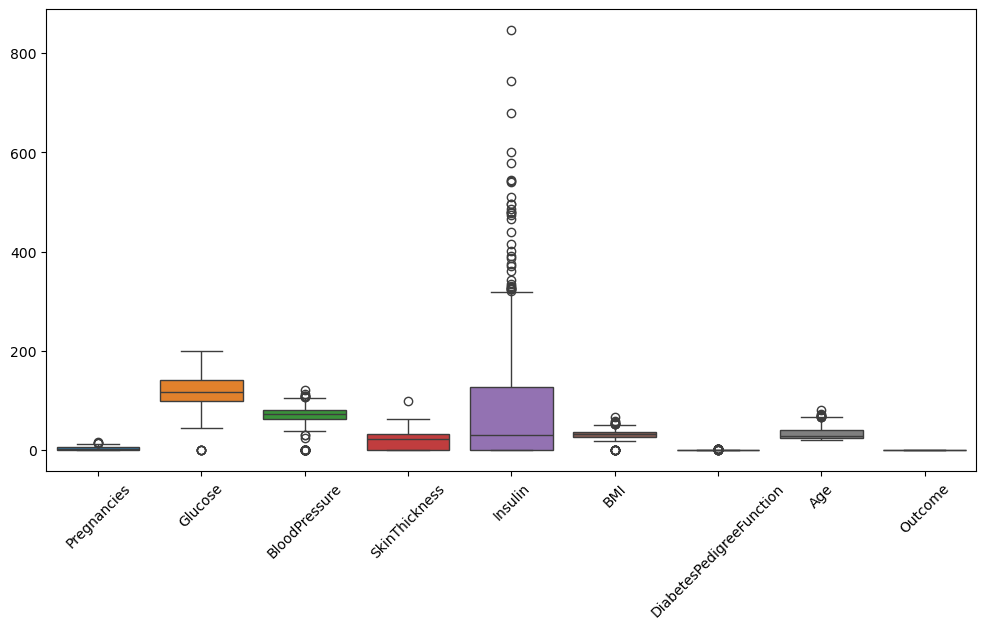

In [32]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

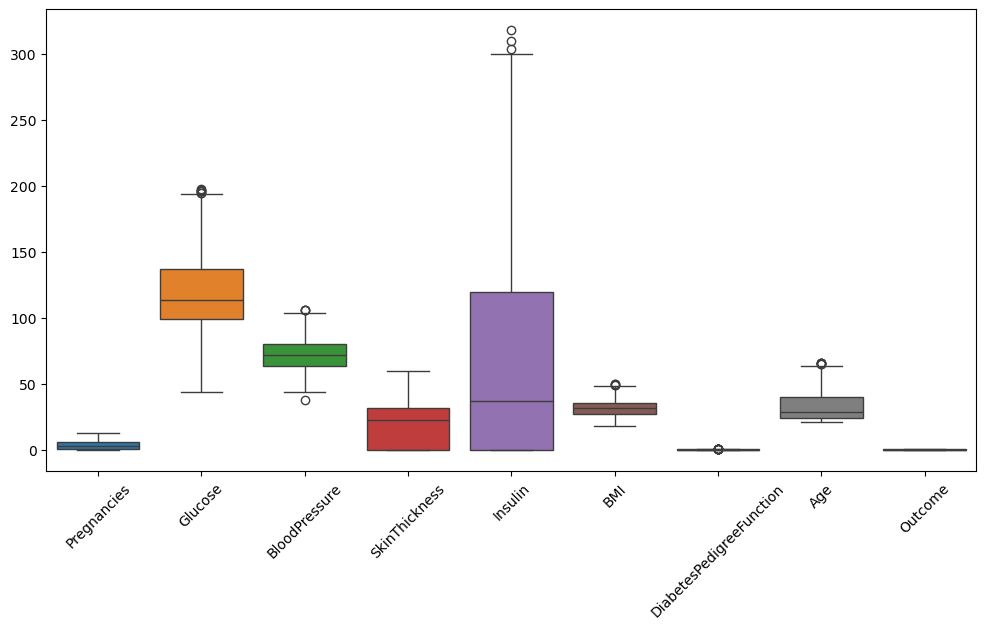

In [33]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()


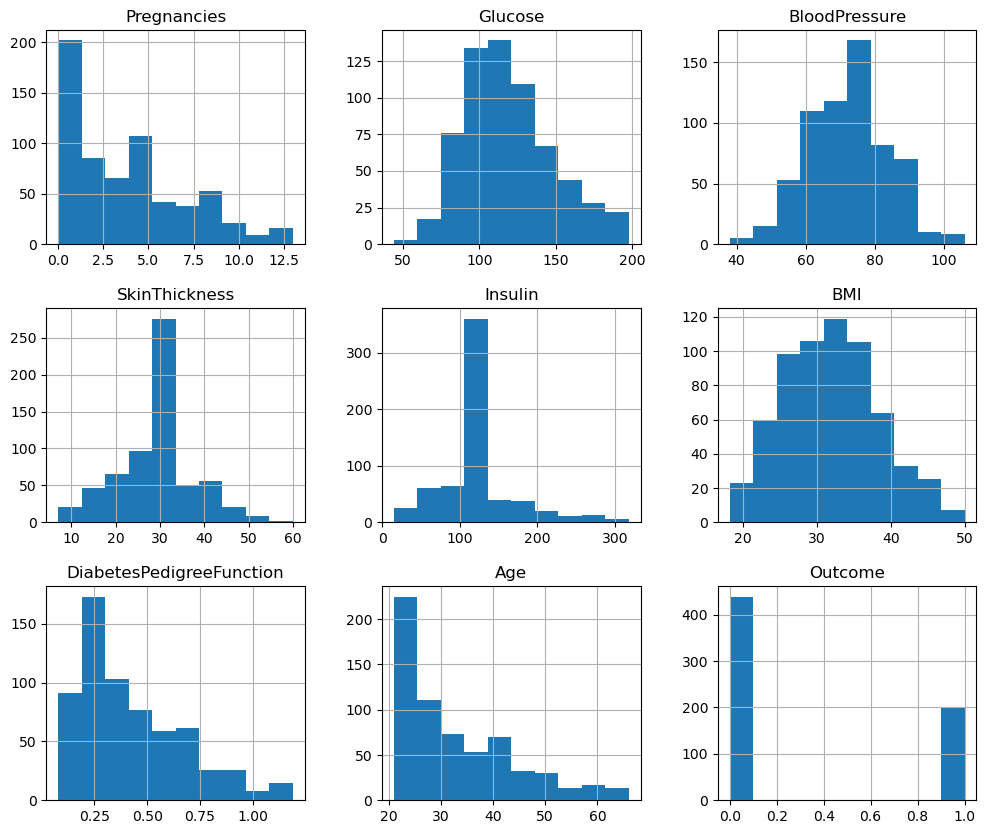

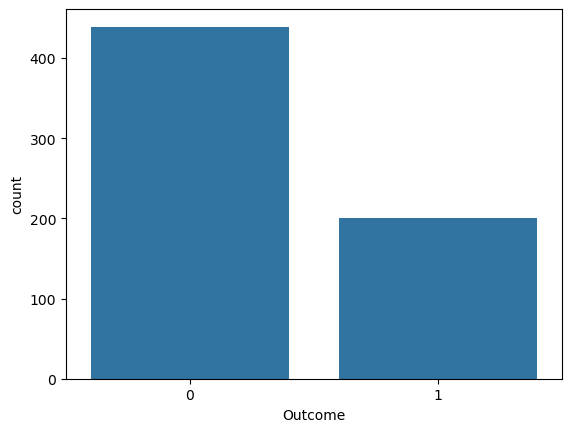

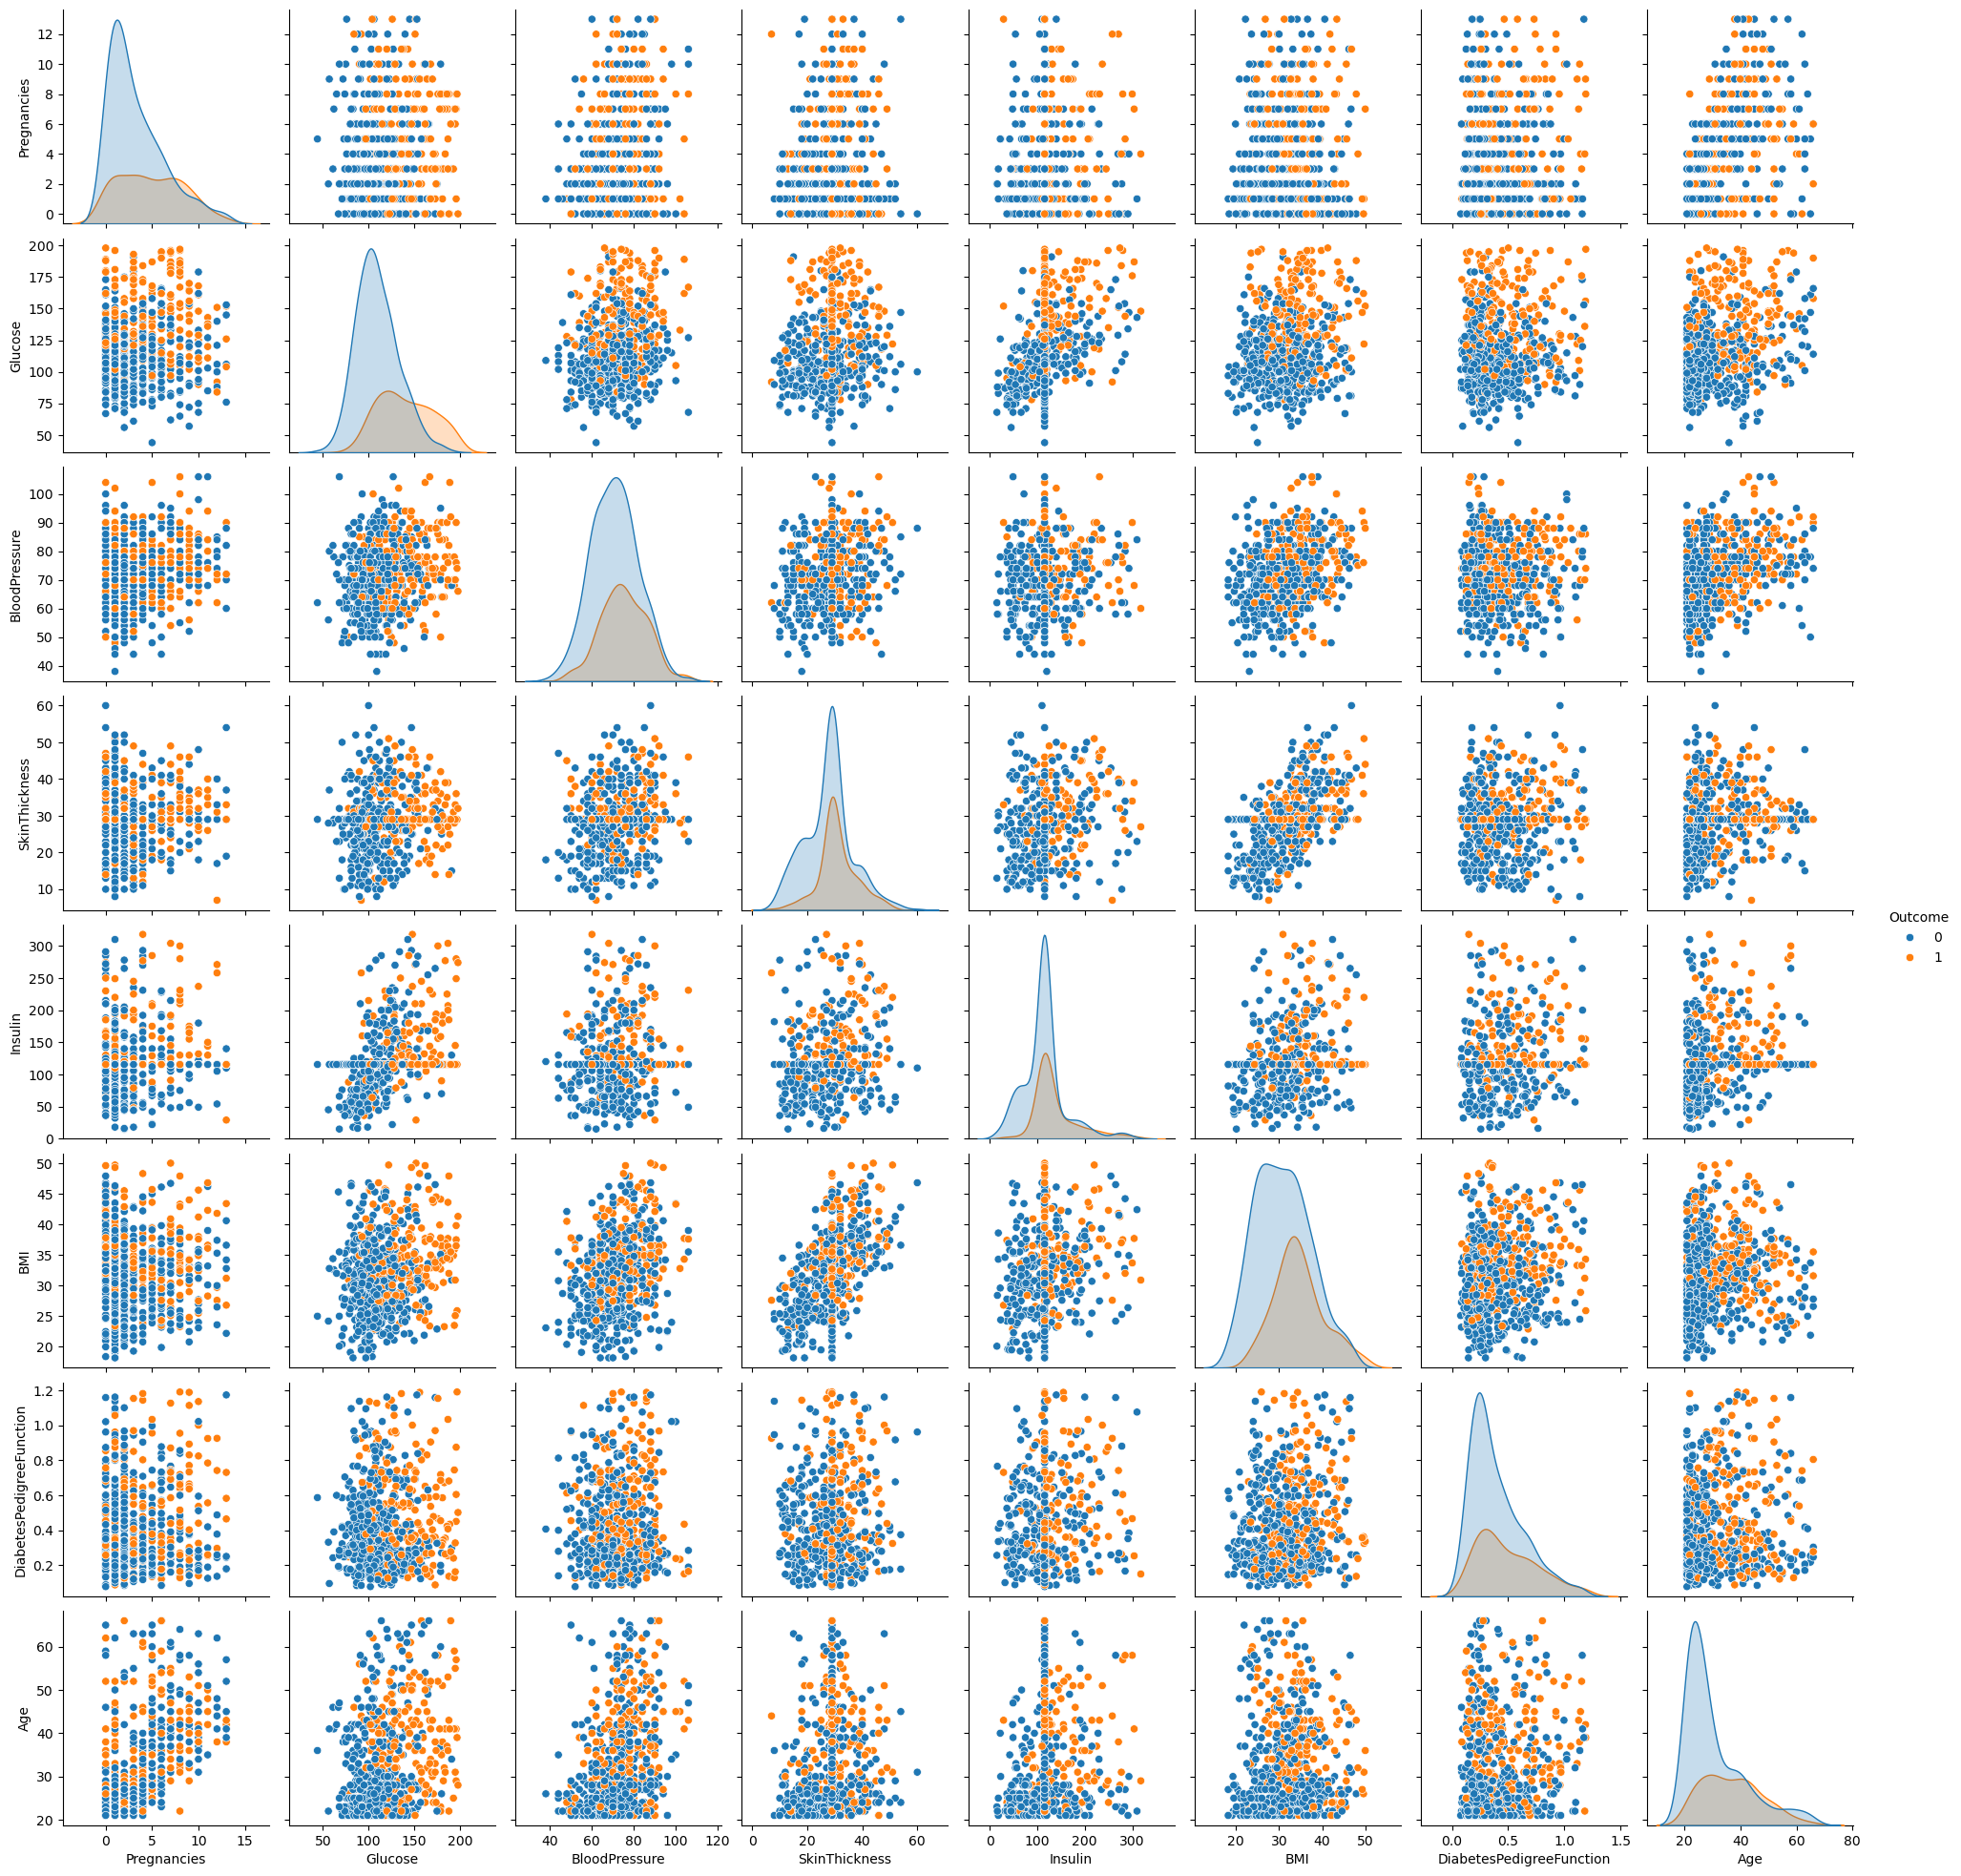

In [34]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

df[cols_with_zero] = df[cols_with_zero].fillna(df[cols_with_zero].median())
# Exploratory Data Analysis (EDA)
df.hist(figsize=(12,10))
plt.show()
sns.countplot(x='Outcome', data=df)
plt.show()
sns.pairplot(df, hue='Outcome')
plt.show()

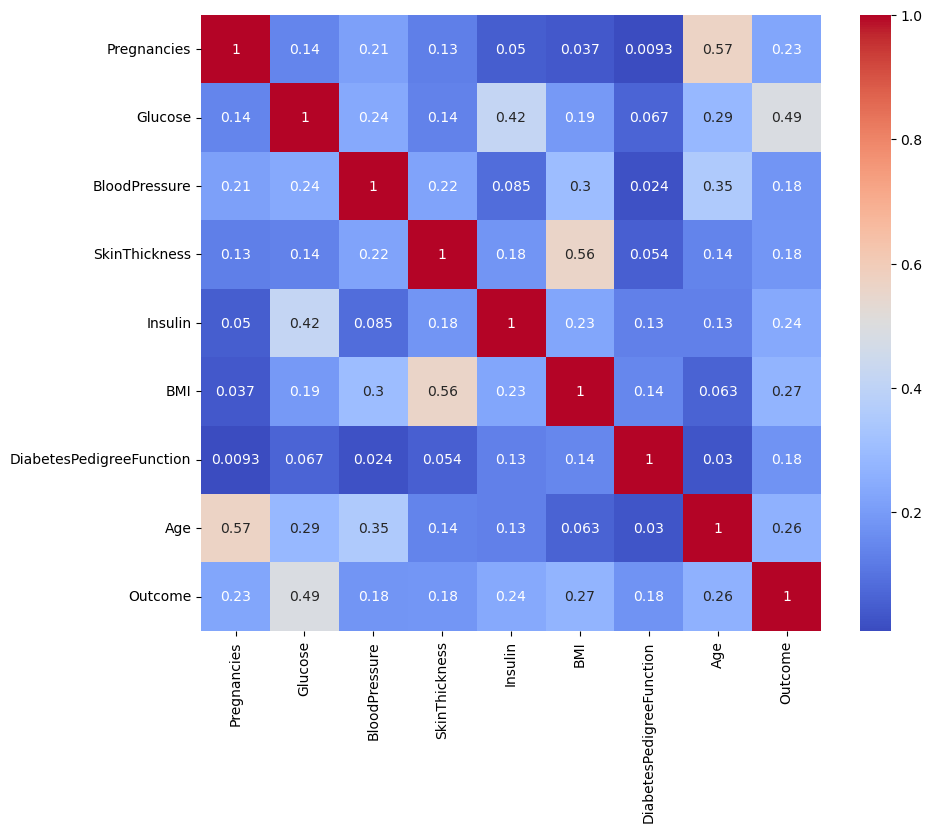

In [35]:
corr = df.corr()
corr

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

<Axes: xlabel='Age', ylabel='Outcome'>

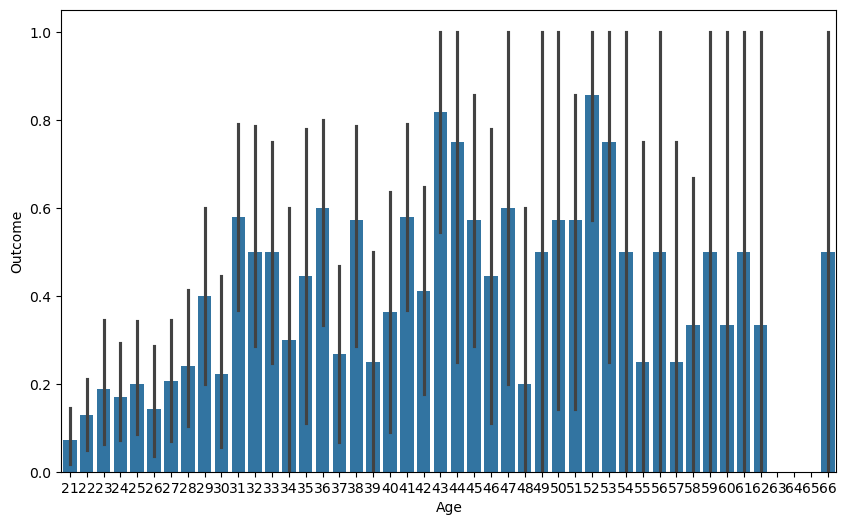

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(x='Age', y='Outcome', data=df)

In [37]:
df.groupby('Outcome')['Age'].mean()
df.groupby('Outcome')['Age'].describe()



,count,mean,std,min,25%,50%,75%,max
Outcome,,,,,,,,
0,439.0,30.747153,10.797316,21.0,23.0,27.0,36.0,66.0
1,200.0,37.035000,10.475805,21.0,29.0,36.0,44.0,66.0


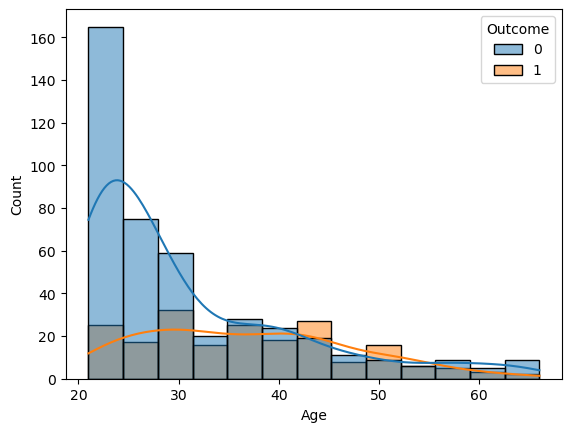

In [38]:
sns.histplot(x="Age",hue="Outcome",data=df,kde=True)
plt.show()

In [39]:
df['Outcome'].value_counts()

Outcome
0    439
1    200
Name: count, dtype: int64

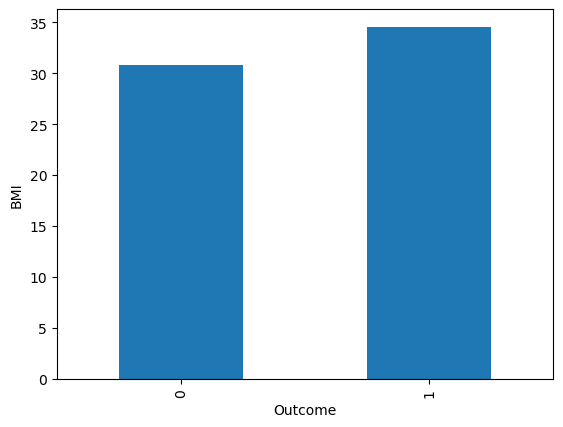

In [40]:
df['BMI'].groupby(df["Outcome"]).mean().plot(kind='bar')
plt.xlabel('Outcome')
plt.ylabel('BMI')
plt.show()

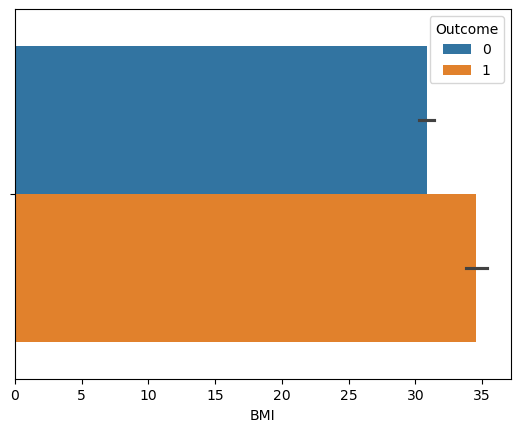

In [41]:
sns.barplot(x='BMI', hue='Outcome', data=df,estimator='mean')
plt.show()

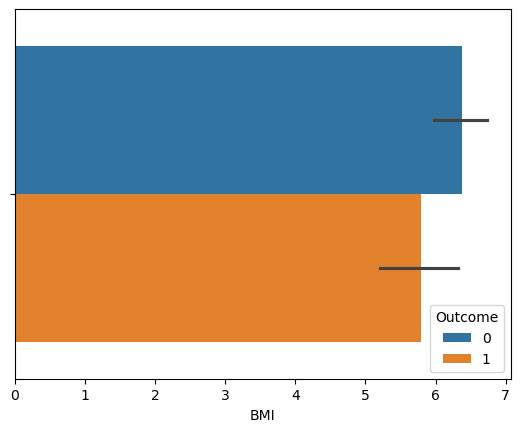

In [42]:
sns.barplot(x='BMI', hue='Outcome', data=df,estimator='std')
plt.show()

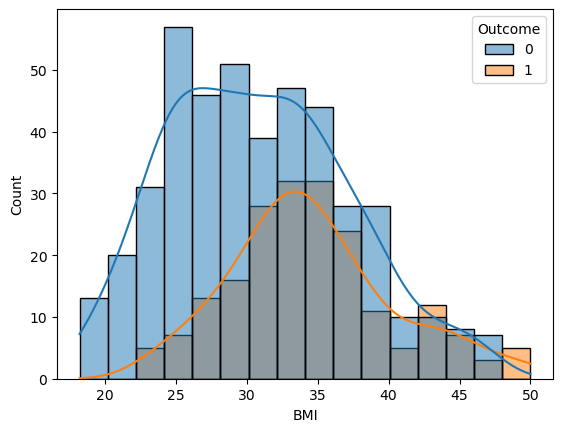

In [43]:
sns.histplot(data=df, x='BMI', hue='Outcome', kde=True)
plt.show()

In [44]:
die_age=df[df['Outcome']==1]['Age']
nondie_age=df[df['Outcome']==0]["Age"]


In [45]:
# H0 : Both data are same
# H1 : Both data are different
from scipy.stats import ttest_ind
stat,p=ttest_ind(die_age, nondie_age)

alpha=0.05
if p<alpha:
    print('Reject H0')
else:
    print('Accept H0')

Reject H0


In [46]:
die_bmi=df[df['Outcome']==1]['BMI']
nondie_bmi=df[df['Outcome']==0]["BMI"]
# H0 : Both data are same
# H1 : Both data are different
from scipy.stats import ttest_ind
stat,p=ttest_ind(die_bmi, nondie_bmi)

alpha=0.05
if p<alpha:
    print('Reject H0')
else:
    print('Accept H0')

Reject H0


## Insights
->Regecting H0 wrt BMI,Age,etc tells that both are not same in outcome

In [47]:
from sklearn.preprocessing import MinMaxScaler
st=MinMaxScaler()
X=df.drop('Outcome',axis=1)
y=df['Outcome']
X_scaled=st.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled,columns=X.columns)
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.461538,0.675325,0.500000,0.528302,0.331683,0.484277,0.493261,0.644444
1,0.076923,0.266234,0.411765,0.415094,0.331683,0.264151,0.245283,0.222222
2,0.615385,0.902597,0.382353,0.415094,0.331683,0.160377,0.533693,0.244444
3,0.076923,0.292208,0.411765,0.301887,0.260726,0.311321,0.079964,0.000000
4,0.384615,0.467532,0.529412,0.415094,0.331683,0.232704,0.110512,0.200000


In [48]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.2f}')
conf_matrix=confusion_matrix(y_test,y_pred)
print('Confusion Matrix:')
print(conf_matrix)
class_report=classification_report(y_test,y_pred)
print('Classification Report:')
print(class_report)


Accuracy: 0.80
Confusion Matrix:
[[125   7]
 [ 31  29]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       132
           1       0.81      0.48      0.60        60

    accuracy                           0.80       192
   macro avg       0.80      0.72      0.74       192
weighted avg       0.80      0.80      0.79       192



In [57]:
from sklearn.metrics import precision_score, recall_score,f1_score,roc_auc_score,roc_curve
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
y_prob=model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

Precision: 0.8055555555555556
Recall: 0.48333333333333334
F1 Score: 0.6041666666666666


ROC AUC Score: 0.859469696969697


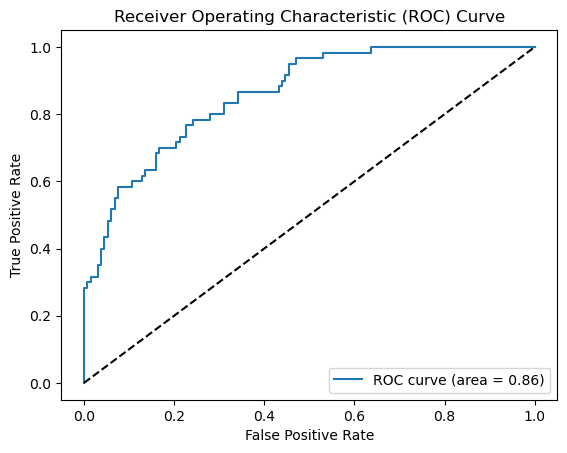

In [59]:
roc_score=roc_auc_score(y_test, y_prob[:, 1])
print("ROC AUC Score:", roc_score)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_score)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()